In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def generate_synthetic_data():
    print("Generating synthetic energy data...")
    # Create date range for 6 months: Jan 2023 to June 2023
    date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='H')
    
    # Create DataFrame
    df = pd.DataFrame(date_rng, columns=['timestamp'])
    
    # Simulate device power consumption (Watts)
    
    # 1. Fridge: Cyclic pattern (Compressor On/Off) + Base load
    # Randomly switching between low (idle) and high (cooling) states
    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])
    
    # 2. AC: Higher in summer (April-June), lower in winter (Jan-March)
    month = df['timestamp'].dt.month
    # Higher probability of AC being ON in months 4, 5, 6
    ac_prob = np.where(month >= 4, 0.8, 0.1) 
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)
    
    # 3. Lights: Higher usage at night (18:00 - 06:00)
    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)
    
    # 4. Microwave: Random usage spikes
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.95, 0.05])
    
    # Total power consumption
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']
    
    # Introduce some random missing values to practice cleaning
    # Set 0.5% of total_power to NaN
    mask = np.random.choice([True, False], size=len(df), p=[0.005, 0.995])
    df.loc[mask, 'total_power'] = np.nan
    
    return df

# Generate and save
df_raw = generate_synthetic_data()
print("Data Generated. Shape:", df_raw.shape)

Generating synthetic energy data...
Data Generated. Shape: (4321, 6)


C:\Users\louis\AppData\Local\Temp\ipykernel_3376\3036332452.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='H')


In [2]:
df_raw.to_csv("Synthetic-Data",index=True)
df_raw.iloc[:30]
df_raw

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,193,0,92,0,285.0
1,2023-01-01 01:00:00,153,0,49,0,202.0
2,2023-01-01 02:00:00,110,0,33,0,143.0
3,2023-01-01 03:00:00,198,0,61,0,259.0
4,2023-01-01 04:00:00,155,0,77,0,232.0
...,...,...,...,...,...,...
4316,2023-06-29 20:00:00,0,1450,54,0,1504.0
4317,2023-06-29 21:00:00,95,2059,78,0,2232.0
4318,2023-06-29 22:00:00,110,1655,36,0,1801.0
4319,2023-06-29 23:00:00,78,2497,79,1035,3689.0


In [3]:
missing = df_raw.isnull().sum()
print("Missing Values per column:\n", missing)

Missing Values per column:
 timestamp       0
fridge          0
ac              0
lights          0
microwave       0
total_power    30
dtype: int64


In [4]:
df_clean = df_raw.fillna(method='ffill')
df_clean.to_csv("Clean-Data",index = False)

C:\Users\louis\AppData\Local\Temp\ipykernel_21056\332814519.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_raw.fillna(method='ffill')


In [5]:
missing_value = df_clean.isnull().sum()
print("Missing Values per column:\n", missing_value)

Missing Values per column:
 timestamp      0
fridge         0
ac             0
lights         0
microwave      0
total_power    0
dtype: int64


In [6]:
df = df_clean.copy()

In [7]:
df['timestamp'] =  pd.to_datetime(df['timestamp'])
df['timestamp']

0      2023-01-01 00:00:00
1      2023-01-01 01:00:00
2      2023-01-01 02:00:00
3      2023-01-01 03:00:00
4      2023-01-01 04:00:00
               ...        
4316   2023-06-29 20:00:00
4317   2023-06-29 21:00:00
4318   2023-06-29 22:00:00
4319   2023-06-29 23:00:00
4320   2023-06-30 00:00:00
Name: timestamp, Length: 4321, dtype: datetime64[ns]

In [8]:
df.set_index('timestamp',inplace=True)

In [9]:
df_daily = df.resample('D').sum()
df_daily.to_csv('timed-data',index=True)
df_daily.head()

,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01,2242,6467,802,0,9511.0
2023-01-02,2237,3550,676,802,7265.0
2023-01-03,2048,1893,687,886,5514.0
2023-01-04,1977,2401,927,0,5305.0
2023-01-05,2702,6472,790,1084,11048.0


In [10]:
df_daily_kWh = df_daily/ 1000

<Figure size 1200x500 with 0 Axes>

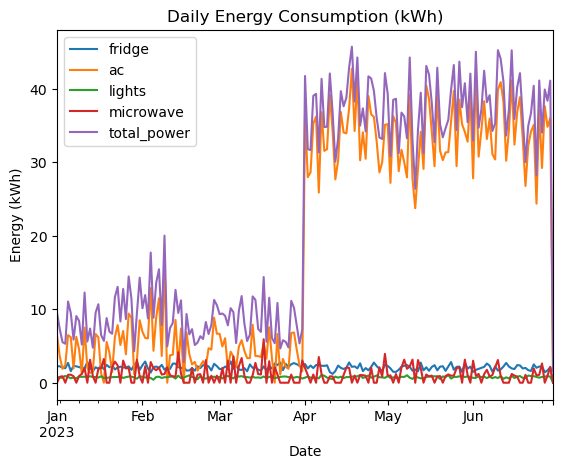

In [11]:
plt.figure(figsize=(12,5))
df_daily_kWh.plot()
plt.title("Daily Energy Consumption (kWh)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Date")
plt.show()

In [12]:
df_weekly_energy = df.resample('W').sum()

df_weekly_energy

,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01,2242,6467,802,0,9511.0
2023-01-08,15078,28702,4998,4750,53528.0
2023-01-15,14576,24733,5657,8125,53143.0
2023-01-22,14767,24796,5110,12063,56914.0
2023-01-29,14787,43274,5429,9313,72985.0
2023-02-05,15255,47836,4756,11015,81155.0
2023-02-12,15000,47922,5391,10036,77405.0
2023-02-19,14158,31444,5496,8177,59376.0
2023-02-26,14523,21170,4644,6287,45587.0


In [13]:
df_weekly_kWh = df_weekly_energy/ 1000

<Figure size 1200x500 with 0 Axes>

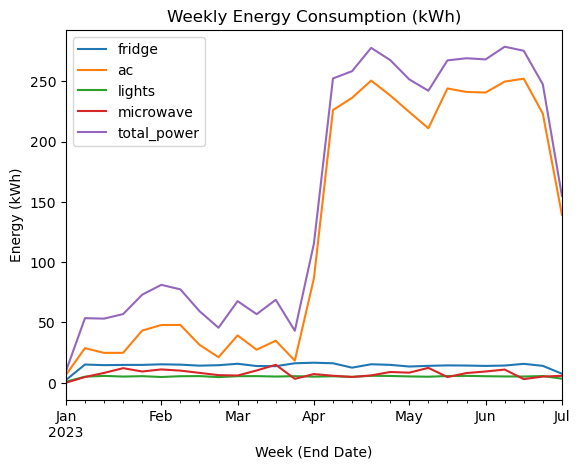

In [14]:
plt.figure(figsize=(12,5))
df_weekly_kWh.plot()
plt.title("Weekly Energy Consumption (kWh)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Week (End Date)")
plt.show()

In [15]:
df_monthly = df.resample('M').sum()
df_monthly

C:\Users\louis\AppData\Local\Temp\ipykernel_21056\2617197382.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M').sum()


,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-31,66000,139514,23429,38241,269889.0
2023-02-28,59223,152344,20382,32486,261548.0
2023-03-31,66679,126248,23421,37426,256256.0
2023-04-30,63235,1015482,23054,28554,1129269.0
2023-05-31,62836,1026494,23873,37550,1148145.0
2023-06-30,58466,998734,22202,29853,1106046.0


In [16]:
df_monthly_kWh = df_monthly / 1000

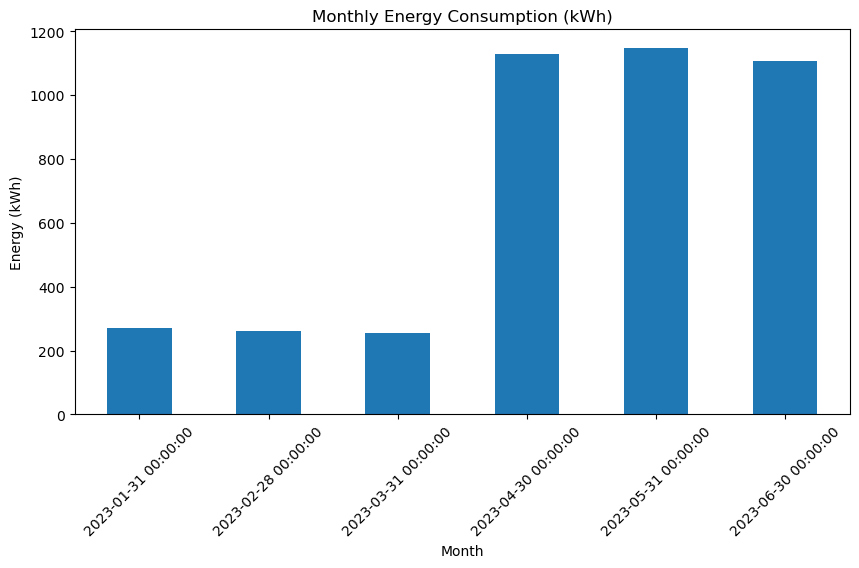

In [17]:
plt.figure(figsize=(10,5))
df_monthly_kWh['total_power'].plot(kind='bar')

plt.title("Monthly Energy Consumption (kWh)")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

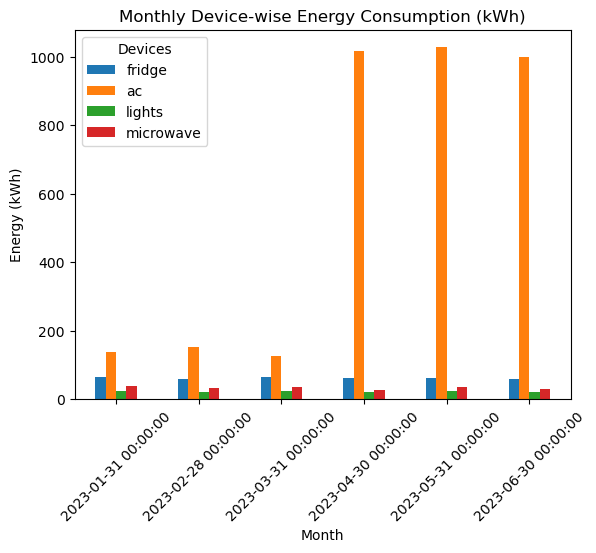

In [18]:
plt.figure(figsize=(12,6))
df_monthly_kWh[['fridge','ac','lights','microwave']].plot(kind='bar')

plt.title("Monthly Device-wise Energy Consumption (kWh)")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.legend(title="Devices")
plt.xticks(rotation=45)
plt.show()

C:\Users\louis\AppData\Local\Temp\ipykernel_21056\804862630.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly_devices = df[['fridge','ac','lights','microwave']].resample('H').sum()


Text(0, 0.5, 'Energy (Wh)')

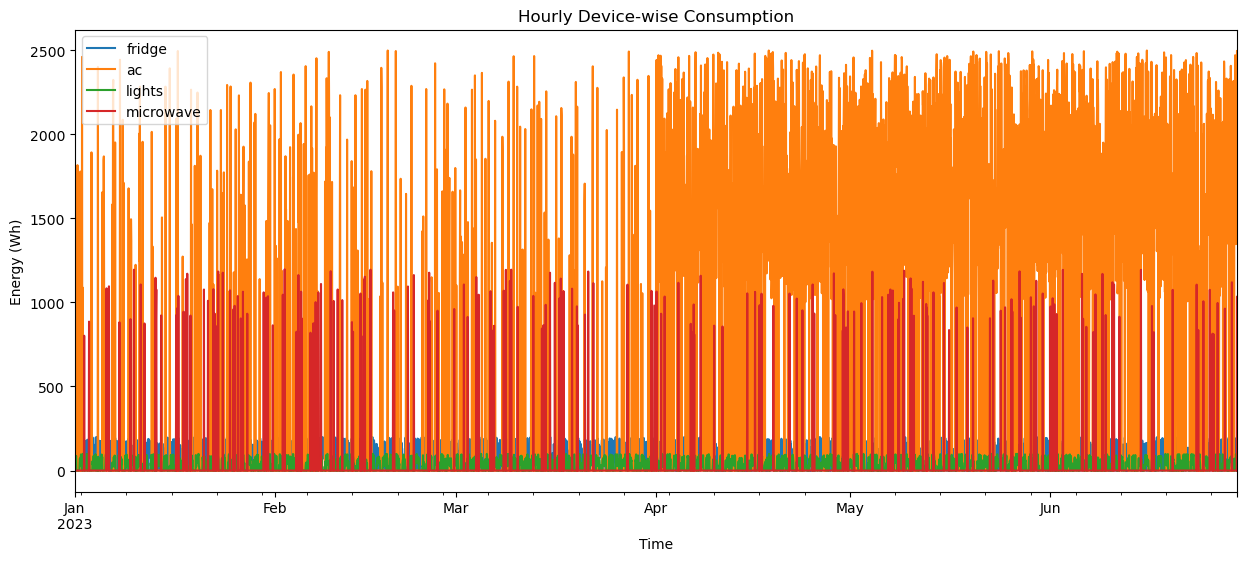

In [19]:
df_hourly_devices = df[['fridge','ac','lights','microwave']].resample('H').sum() 
df_hourly_devices.plot(figsize=(15,6)) 
plt.title("Hourly Device-wise Consumption") 
plt.xlabel("Time") 
plt.ylabel("Energy (Wh)")